<a href="https://colab.research.google.com/github/msiplab/EicEngLabIV/blob/master/example02_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 実験Ⅳ－２　時系列データの分析

1. サンプルデータの読み込み
1. 平均 $\mu$ と分散 $\gamma_0$ の推定
1. 自己共分散関数 $\gamma_k$ と自己相関関数 $\rho_k$ の推定

新潟大学工学部工学科　電子情報通信プログラム

## 準備

In [3]:
!pip install japanize-matplotlib
%matplotlib inline

import warnings
warnings.simplefilter('ignore') #警告を無視（コメントアウト推奨）

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib #日本語化matplotlib
sns.set(font="IPAexGothic") #日本語フォント設定

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 42.5 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=5f159710c30157bcd68d20650e65d57572ade0a0b66fff6e18f106f0f5bdbdae
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


## サンプルデータの読み込み

WAV形式の音響データ（モノラル）を読込

https://docs.python.org/ja/3/library/wave.html#https://docs.python.org/ja/3/library/wave.html#


In [4]:
import wave
import os

# 2026年度版サンプルデータを読み込む
filename = 'example02_01_2026.wav'
local_path = os.path.join('data', filename)

# Colab判定
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive, files

    # Google Driveをマウント
    drive.mount('/content/drive')

    # Drive内の候補パス（必要に応じて自分の構成に合わせて変更）
    drive_candidates = [
        '/content/drive/MyDrive/電子情報通信実験Ⅳ/data/' + filename,
        '/content/drive/MyDrive/data/' + filename,
    ]

    filepath = None
    for p in drive_candidates:
        if os.path.exists(p):
            filepath = p
            break

    # Driveに見つからない場合はアップロード
    if filepath is None:
        print('Google Drive内に対象ファイルが見つからないため、アップロードに切り替えます。')
        uploaded = files.upload()
        filename = next(iter(uploaded))
        filepath = filename
else:
    # ローカル実行
    if os.path.exists(local_path):
        filepath = local_path
    else:
        raise FileNotFoundError(
            f'ファイルが見つかりません: {local_path}\n'
            'data フォルダに配置してください。'
        )

wf = wave.open(filepath, mode='rb')
buf = wf.readframes(-1)
ch = wf.getnchannels()
fs = wf.getframerate()
nf = wf.getnframes()
y = np.frombuffer(buf, dtype='int16')
print('ファイル = {}, チャンネル数 = {:d} ch, 標本化周波数 = {:f} Hz, 長さ {:f} 秒'.format(filename, ch, fs, nf / fs))

# ステレオならモノラルに変換
if ch == 2:
    y = y.reshape(-1, 2)    # 2列（左・右）に変形
    y = y.mean(axis=1).astype('int16')  # 左右平均してint16に戻す

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ファイル = example02_01_2026.wav, チャンネル数 = 2 ch, 標本化周波数 = 48000.000000 Hz, 長さ 5.000000 秒


## 時系列データをpandas.DataFrameオブジェクトに変換

pandas ライブラリの DataFrame オブジェクトに変換

- t: 時刻
- y: データの値

以下では開始から1秒間のデータを抽出して分析を進める。

In [5]:
t = np.linspace(0,nf/fs,nf)
df_full= pd.DataFrame({'t': t, 'y': y})

tstart = 0.0
tend = 1.0
df_timeseries = df_full[(df_full['t'] >= tstart) & (df_full['t'] < tend)].copy()

y_diff_series = df_timeseries['y'].diff().dropna()
display(y_diff_series)

,y
1,-2049.0
2,-3334.0
3,-846.0
4,-3503.0
5,-5071.0
...,...
47995,838.0
47996,588.0
47997,-790.0
47998,-1447.0


## 時系列データをプロット


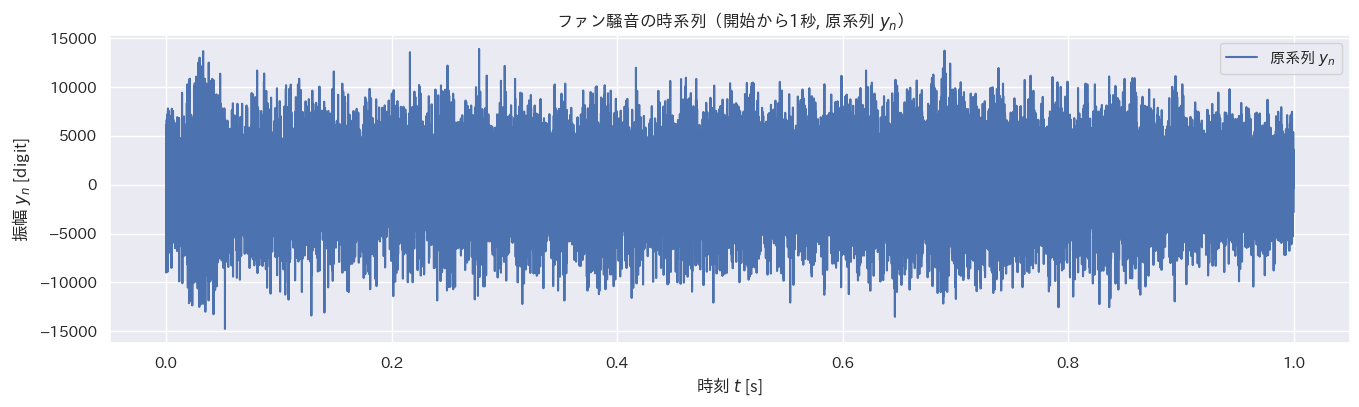

In [6]:
ax = df_timeseries.plot(x='t', y='y', figsize=(16,4), label=r'原系列 $y_n$')
ax.set_title(r'ファン騒音の時系列（開始から1秒, 原系列 $y_n$）')
ax.set_xlabel('時刻 $t$ [s]')
ax.set_ylabel(r'振幅 $y_n$ [digit]')
ax.legend()

ヒストグラムをプロット

Text(0, 0.5, '度数 [count]')

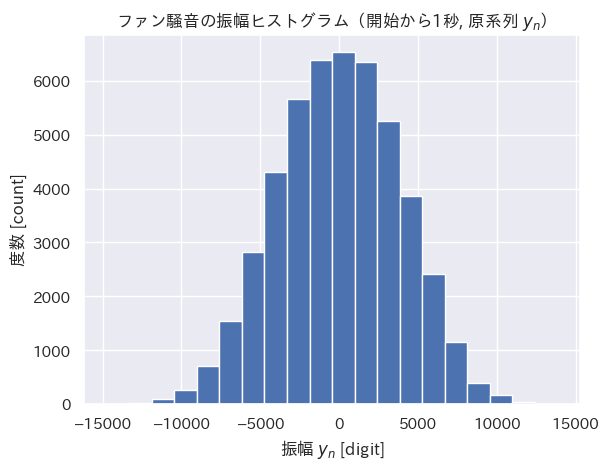

In [7]:
ax = df_timeseries.hist('y', bins=20)
ax0 = ax[0][0]
ax0.set_title(r'ファン騒音の振幅ヒストグラム（開始から1秒, 原系列 $y_n$）')
ax0.set_xlabel(r'振幅 $y_n$ [digit]')
ax0.set_ylabel('度数 [count]')

## 平均 $\mu$ と分散 $\gamma_0$ の推定（階差系列 $y_{diff}$）

定常性を仮定して、階差系列の平均と分散を推定する。

- mean(): 標本平均を計算
- var(): 標本分散を計算

pandas.Series の var() メソッドのオプションで

- ddof = 0 とすると $N$ で割る最尤推定
- ddof = 1 とすると $(N-1)$ で割る不偏推定

In [8]:
y_diff_series = df_timeseries['y'].diff().dropna()
mu = y_diff_series.mean()
gamma0_unbiased = y_diff_series.var(ddof=1)
gamma0_mle = y_diff_series.var(ddof=0)
print('対象: 階差系列 y_diff（開始から1秒）')
print('平均 μ = {:f}'.format(mu))
print('分散 γ0（不偏推定） = {:f}'.format(gamma0_unbiased))
print('分散 γ0（最尤推定） = {:f}'.format(gamma0_mle))

対象: 階差系列 y_diff（開始から1秒）
平均 μ = -0.129544
分散 γ0（不偏推定） = 6303989.500000
分散 γ0（最尤推定） = 6303858.500000


In [9]:
# 写真の計算式と同じ条件（原系列 y, ddof=1）で再計算
y_series = df_timeseries['y']
mu_photo = y_series.mean()
gamma0_photo = y_series.var(ddof=1)

print('【写真と同じ計算条件】対象: 原系列 y（開始から1秒）')
print('平均 = {:f}, 分散 = {:f}'.format(mu_photo, gamma0_photo))

# 参考: いままで表示していた階差系列の結果
y_diff_series = df_timeseries['y'].diff().dropna()
mu_diff = y_diff_series.mean()
gamma0_diff = y_diff_series.var(ddof=1)

print('【比較】対象: 階差系列 y_diff（開始から1秒）')
print('平均 = {:f}, 分散 = {:f}'.format(mu_diff, gamma0_diff))

【写真と同じ計算条件】対象: 原系列 y（開始から1秒）
平均 = 0.287604, 分散 = 14840514.527149
【比較】対象: 階差系列 y_diff（開始から1秒）
平均 = -0.129544, 分散 = 6303989.500000


## 自己共分散関数 $\gamma_k$ と自己相関関数 $\rho_k$ の推定（階差系列 $y_{diff}$）

ここでは階差系列 $y_{diff}$ を pandas.Series として扱う。

- cov() は共分散の不偏推定を計算
- corr() は相関の不偏推定を計算

In [10]:
nlags = 40
for lag in range(nlags + 1):
    gammak = y_diff_series.cov(y_diff_series.shift(lag))
    rhok = y_diff_series.corr(y_diff_series.shift(lag))
    print('γ{0:d} = {1:f}, ρ{0:d} = {2:f}'.format(lag, gammak, rhok))

γ0 = 6304025.735833, ρ0 = 1.000000
γ1 = 3461155.519858, ρ1 = 0.549034
γ2 = -363052.841891, ρ2 = -0.057590
γ3 = -1410444.858725, ρ3 = -0.223731
γ4 = -2706552.151565, ρ4 = -0.429326
γ5 = -3986491.632577, ρ5 = -0.632370
γ6 = -2698384.480045, ρ6 = -0.428033
γ7 = -582935.763339, ρ7 = -0.092471
γ8 = 1048197.157921, ρ8 = 0.166274
γ9 = 2877214.633663, ρ9 = 0.456405
γ10 = 3480127.115363, ρ10 = 0.552053
γ11 = 2035194.226762, ρ11 = 0.322836
γ12 = 338165.616181, ρ12 = 0.053642
γ13 = -936360.451283, ρ13 = -0.148532
γ14 = -2252457.112612, ρ14 = -0.357312
γ15 = -2854057.822182, ρ15 = -0.452740
γ16 = -2190966.759101, ρ16 = -0.347549
γ17 = -893677.077324, ρ17 = -0.141761
γ18 = 767526.053383, ρ18 = 0.121748
γ19 = 2537560.249024, ρ19 = 0.402527
γ20 = 3140150.471621, ρ20 = 0.498111
γ21 = 2084078.910134, ρ21 = 0.330587
γ22 = 492566.655287, ρ22 = 0.078132
γ23 = -1090235.477029, ρ23 = -0.172932
γ24 = -2605862.653901, ρ24 = -0.413336
γ25 = -2949761.122310, ρ25 = -0.467891
γ26 = -1853993.182836, ρ26 = -0.29407

## 時系列解析ライブラリ

時系列解析には，statsmodelsライブラリも利用できる。

- acovf() は自己共分散関数を計算
- acf() は自己相関関数を計算

各メソッドのオプション unbiased = True で不偏推定，Falseで最尤推定となる．


自己共分散関数 γ̂k と自己相関関数 ρ̂k（k=0〜40）


k,γ̂k,ρ̂k
0,"6,304,025.7358",1.000000
1,"3,461,155.5199",0.549034
2,"-363,052.8419",-0.057590
3,"-1,410,444.8587",-0.223731
4,"-2,706,552.1516",-0.429326
5,"-3,986,491.6326",-0.632370
6,"-2,698,384.4800",-0.428033
7,"-582,935.7633",-0.092471
8,"1,048,197.1579",0.166274
9,"2,877,214.6337",0.456405


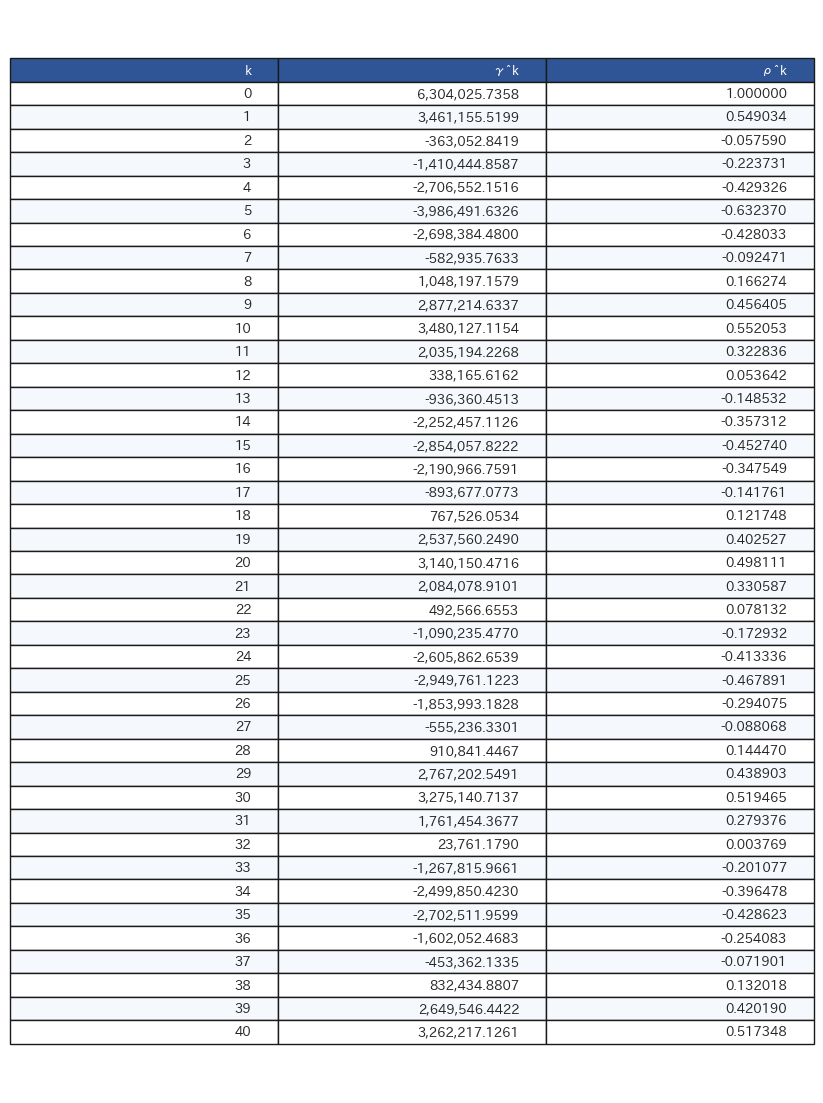

表画像を autocov_acf_table_k0_40.png に保存しました。


In [24]:
import statsmodels.api as sm
from statsmodels.tsa import stattools

lags = np.arange(nlags + 1)

# pandas.cov/corr と同じ定義で計算（ラグごとに有効データ対で平均を取り直す）
gamma_all = np.array([y_diff_series.cov(y_diff_series.shift(k)) for k in lags])
rho_all = np.array([y_diff_series.corr(y_diff_series.shift(k)) for k in lags])

result_all = pd.DataFrame({
    'k': lags,
    'γ̂k': gamma_all,
    'ρ̂k': rho_all,
})

print('自己共分散関数 γ̂k と自己相関関数 ρ̂k（k=0〜40）')
display(
    result_all.style
    .hide(axis='index')
    .format({'k': '{:d}', 'γ̂k': '{:,.4f}', 'ρ̂k': '{:.6f}'})
    .set_properties(**{'text-align': 'right', 'font-family': 'monospace', 'font-size': '11pt'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'right'), ('background-color', '#f0f4fa')]},
        {'selector': 'caption', 'props': [('caption-side', 'top'), ('font-size', '12pt')]},
    ])
    .set_caption('自己共分散関数と自己相関関数（k=0〜40）')
)

# スクショしやすいように、表を画像としても保存
fig, ax = plt.subplots(figsize=(8.4, 11.2))
ax.axis('off')

table_data = [[f"{int(k)}", f"{g:,.4f}", f"{r:.6f}"] for k, g, r in zip(lags, gamma_all, rho_all)]
tbl = ax.table(
    cellText=table_data,
    colLabels=['k', 'γ̂k', 'ρ̂k'],
    cellLoc='right',
    colLoc='right',
    loc='center',
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1.0, 1.12)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2f5597')
    elif row % 2 == 0:
        cell.set_facecolor('#f5f8fc')

plt.tight_layout()
plt.savefig('autocov_acf_table_k0_40.png', dpi=220, bbox_inches='tight')
plt.show()
print('表画像を autocov_acf_table_k0_40.png に保存しました。')

## 階差系列のコレログラムの表示

自己相関のグラフをコレログラムとよぶ。ここでは階差系列 $y_{diff}$ のコレログラムを表示する。

Text(0, 0.5, '自己相関 $\\hat{\\rho}_k$ [-]')

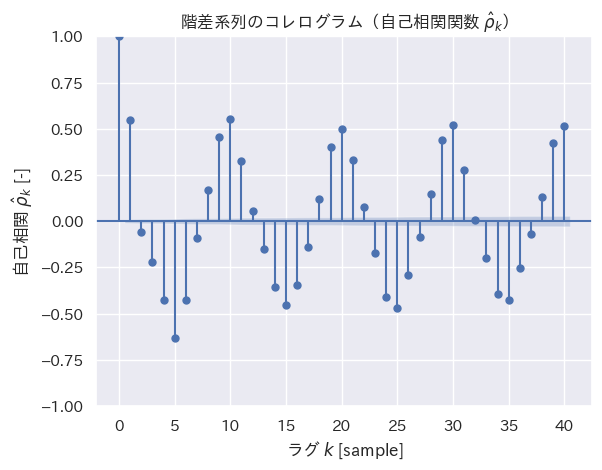

In [12]:
fig = sm.graphics.tsa.plot_acf(y_diff_series, lags=nlags)
ax = fig.axes[0]
ax.set_title(r'階差系列のコレログラム（自己相関関数 $\hat{\rho}_k$）')
ax.set_xlabel('ラグ $k$ [sample]')
ax.set_ylabel(r'自己相関 $\hat{\rho}_k$ [-]')

## 階差系列の自己共分散関数の表示

自己相関関数の図と同じデザインで、自己共分散関数 $\gamma_k$ を表示する。

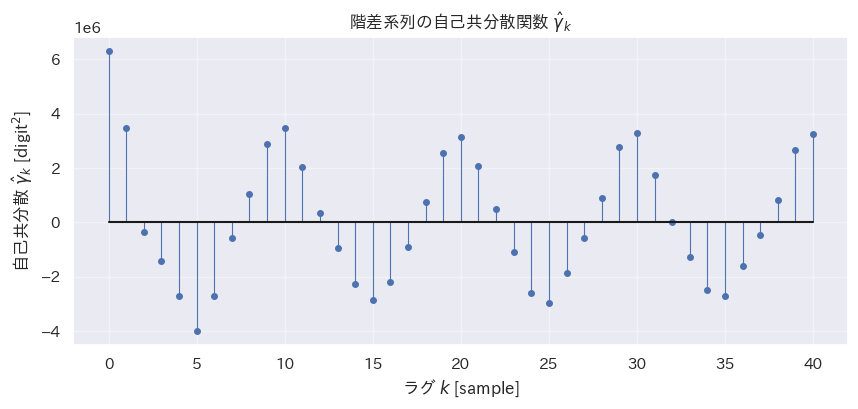

In [13]:
lags_cov = np.arange(nlags + 1)
gamma_cov = np.array([y_diff_series.cov(y_diff_series.shift(lag)) for lag in lags_cov])

fig, ax = plt.subplots(figsize=(10, 4))
markerline, stemlines, baseline = ax.stem(
    lags_cov, gamma_cov, linefmt='C0-', markerfmt='C0o', basefmt='k-'
 )
plt.setp(markerline, markersize=4)
plt.setp(stemlines, linewidth=0.8)

ax.set_title(r'階差系列の自己共分散関数 $\hat{\gamma}_k$')
ax.set_xlabel('ラグ $k$ [sample]')
ax.set_ylabel(r'自己共分散 $\hat{\gamma}_k$ [digit$^2$]')
ax.grid(True, alpha=0.4)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ファイルパス: /content/drive/MyDrive/電子情報通信実験Ⅳ/data/example02_01_2026.wav
チャンネル数: 2 ch
標本化周波数: 48000 Hz
長さ: 5.0 秒  (240000 サンプル)

分析区間: 0〜1秒  (N = 48000 サンプル)

【平均・分散の推定結果】
  平均 μ̂              = -0.129544
  分散 γ̂₀（不偏, ddof=1）= 6303989.5000
  分散 γ̂₀（最尤, ddof=0）= 6303858.5000

自己共分散関数 γ̂k】
    k               γ̂k          ρ̂k
    0      6304025.7358     1.000000
    1      3461155.5199     0.549034
    2      -363052.8419    -0.057590
    3     -1410444.8587    -0.223731
    4     -2706552.1516    -0.429326
    5     -3986491.6326    -0.632370
   10      3480127.1154     0.552053
   20      3140150.4716     0.498111
   30      3275140.7137     0.519465
   40      3262217.1261     0.517348

【方法B: statsmodels acovf() による自己共分散関数】
    k      γ̂k (statsmodels)
    0           6303894.3992
    1           3461083.4110
    2           -363045.2703
    3          -1410415.4

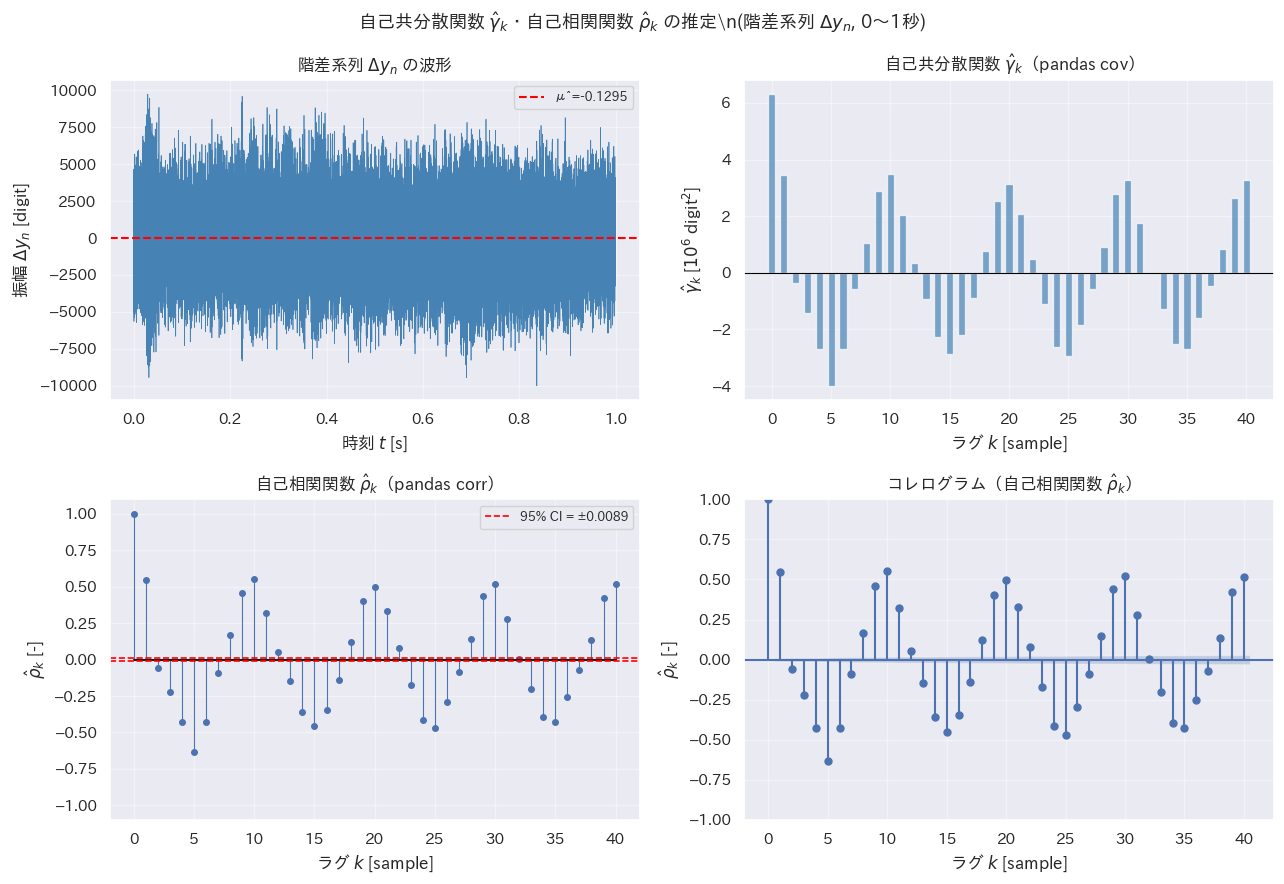


図を autocovariance_result.png に保存しました。

【推定結果一覧（先頭11行）】
 lag_k       gamma_k     rho_k    gamma_k_sm  rho_k_sm
     0  6.304026e+06  1.000000  6.303894e+06  1.000000
     1  3.461156e+06  0.549034  3.461083e+06  0.549039
     2 -3.630528e+05 -0.057590 -3.630453e+05 -0.057591
     3 -1.410445e+06 -0.223731 -1.410415e+06 -0.223737
     4 -2.706552e+06 -0.429326 -2.706496e+06 -0.429337
     5 -3.986492e+06 -0.632370 -3.986409e+06 -0.632372
     6 -2.698384e+06 -0.428033 -2.698328e+06 -0.428041
     7 -5.829358e+05 -0.092471 -5.829236e+05 -0.092470
     8  1.048197e+06  0.166274  1.048175e+06  0.166274
     9  2.877215e+06  0.456405  2.877155e+06  0.456409
    10  3.480127e+06  0.552053  3.480055e+06  0.552048


In [14]:
# ============================================================
#  自己共分散関数の推定 (Google Colab 動作確認済み)
#  対象: example02_01_2026.wav
# ============================================================

import os
import wave
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa import stattools

# ── 1. WAV ファイルの場所を決定（Google Drive優先） ───────────
filename = 'example02_01_2026.wav'
local_path = os.path.join('data', filename)

# Colab 判定
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive, files

    # Google Drive をマウント
    drive.mount('/content/drive')

    # Drive 内の候補パス（必要に応じて追加・変更）
    drive_candidates = [
        '/content/drive/MyDrive/電子情報通信実験Ⅳ/data/' + filename,
        '/content/drive/MyDrive/data/' + filename,
    ]

    filepath = None
    for p in drive_candidates:
        if os.path.exists(p):
            filepath = p
            break

    # Drive に見つからない場合はアップロードにフォールバック
    if filepath is None:
        print('Google Drive 内に対象ファイルが見つからないため、アップロードに切り替えます。')
        uploaded = files.upload()
        filename = next(iter(uploaded))
        filepath = filename
else:
    # ローカル実行
    if os.path.exists(local_path):
        filepath = local_path
    else:
        raise FileNotFoundError(
            f'ファイルが見つかりません: {local_path}\n'
            'data フォルダに配置してください。'
        )

# ── 2. WAV ファイルの読み込み ────────────────────────────────
wf  = wave.open(filepath, mode='rb')
buf = wf.readframes(-1)
ch  = wf.getnchannels()
fs  = wf.getframerate()
nf  = wf.getnframes()
wf.close()

print(f'ファイルパス: {filepath}')
print(f'チャンネル数: {ch} ch')
print(f'標本化周波数: {fs} Hz')
print(f'長さ: {nf/fs:.1f} 秒  ({nf} サンプル)')

# ── 3. ステレオ → モノラル変換 ───────────────────────────────
y = np.frombuffer(buf, dtype='int16')
if ch == 2:
    y = y.reshape(-1, 2).mean(axis=1).astype('int16')

# ── 4. 最初の1秒を切り出し、DataFrame に変換 ─────────────────
t  = np.arange(len(y)) / fs
df = pd.DataFrame({'t': t, 'y': y})
df = df[df['t'] < 1.0].copy()
print(f'\n分析区間: 0〜1秒  (N = {len(df)} サンプル)')

# ── 5. 階差系列の計算 ────────────────────────────────────────
df['y_diff'] = df['y'].diff()
y_diff = df['y_diff'].dropna()

# ── 6. 平均・分散の確認 ──────────────────────────────────────
mu          = y_diff.mean()
gamma0_ub   = y_diff.var(ddof=1)   # 不偏推定 (ddof=1)
gamma0_mle  = y_diff.var(ddof=0)   # 最尤推定 (ddof=0)

print('\n【平均・分散の推定結果】')
print(f'  平均 μ̂              = {mu:.6f}')
print(f'  分散 γ̂₀（不偏, ddof=1）= {gamma0_ub:.4f}')
print(f'  分散 γ̂₀（最尤, ddof=0）= {gamma0_mle:.4f}')

# ── 7. 自己共分散関数の推定 ──────────────────────────────────
nlags = 40

# --- 方法 A: pandas cov() を使う（不偏推定, 分母 = N-1-k）---
print('\n自己共分散関数 γ̂k】')
print(f'  {"k":>3}   {"γ̂k":>15}   {"ρ̂k":>10}')
gamma_pd = []
rho_pd   = []
for k in range(nlags + 1):
    gk = y_diff.cov(y_diff.shift(k))    # 不偏推定（分母: N-1-k）
    rk = y_diff.corr(y_diff.shift(k))   # = gk / g0
    gamma_pd.append(gk)
    rho_pd.append(rk)
    if k <= 5 or k in [10, 20, 30, 40]:
        print(f'  {k:3d}   {gk:15.4f}   {rk:10.6f}')

gamma_pd = np.array(gamma_pd)
rho_pd   = np.array(rho_pd)

# --- 方法 B: statsmodels acovf() を使う ----------------------
print('\n【方法B: statsmodels acovf() による自己共分散関数】')
try:
    # statsmodels >= 0.12 では adjusted オプションを使用
    y_acovf = stattools.acovf(y_diff, adjusted=True, nlag=nlags)
except TypeError:
    y_acovf = stattools.acovf(y_diff, unbiased=True)[:nlags + 1]

print(f'  {"k":>3}   {"γ̂k (statsmodels)":>20}')
for k in [0, 1, 2, 3, 4, 5, 10, 20, 30, 40]:
    print(f'  {k:3d}   {y_acovf[k]:20.4f}')

# 自己相関関数（statsmodels）
try:
    y_acf = stattools.acf(y_diff, adjusted=True, nlags=nlags)
except TypeError:
    y_acf = stattools.acf(y_diff, unbiased=True, nlags=nlags)

# ── 8. グラフの描画 ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(r'自己共分散関数 $\hat{\gamma}_k$・自己相関関数 $\hat{\rho}_k$ の推定\n(階差系列 $\Delta y_n$, 0〜1秒)', fontsize=13)

lags = np.arange(nlags + 1)
ci   = 1.96 / np.sqrt(len(y_diff))   # 95% 信頼区間

# (a) 階差系列 波形
ax = axes[0, 0]
ax.plot(df['t'], df['y_diff'], linewidth=0.5, color='steelblue')
ax.axhline(mu, color='red', linewidth=1.5, linestyle='--', label=f'μ̂={mu:.4f}')
ax.set_title(r'階差系列 $\Delta y_n$ の波形')
ax.set_xlabel('時刻 $t$ [s]')
ax.set_ylabel(r'振幅 $\Delta y_n$ [digit]')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

# (b) 自己共分散関数（棒グラフ）
ax = axes[0, 1]
ax.bar(lags, gamma_pd / 1e6, color='steelblue', alpha=0.7, width=0.6)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(r'自己共分散関数 $\hat{\gamma}_k$（pandas cov）')
ax.set_xlabel('ラグ $k$ [sample]')
ax.set_ylabel(r'$\hat{\gamma}_k$ [$10^6$ digit$^2$]')
ax.grid(True, alpha=0.4)

# (c) 自己相関関数（stem）
ax = axes[1, 0]
markerline, stemlines, baseline = ax.stem(lags, rho_pd, linefmt='C0-',
                                           markerfmt='C0o', basefmt='k-')
plt.setp(markerline, markersize=4)
plt.setp(stemlines, linewidth=0.8)
ax.axhline( ci, color='red', linewidth=1.2, linestyle='--', label=f'95% CI = ±{ci:.4f}')
ax.axhline(-ci, color='red', linewidth=1.2, linestyle='--')
ax.set_title(r'自己相関関数 $\hat{\rho}_k$（pandas corr）')
ax.set_xlabel('ラグ $k$ [sample]')
ax.set_ylabel(r'$\hat{\rho}_k$ [-]')
ax.set_ylim(-1.1, 1.1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

# (d) コレログラム（statsmodels plot_acf）
ax = axes[1, 1]
sm.graphics.tsa.plot_acf(y_diff, lags=nlags, ax=ax, alpha=0.05)
ax.set_title(r'コレログラム（自己相関関数 $\hat{\rho}_k$）')
ax.set_xlabel('ラグ $k$ [sample]')
ax.set_ylabel(r'$\hat{\rho}_k$ [-]')
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('autocovariance_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n図を autocovariance_result.png に保存しました。')

# ── 9. 結果の DataFrame 出力 ─────────────────────────────────
result_df = pd.DataFrame({
    'lag_k':        lags,
    'gamma_k':      gamma_pd,
    'rho_k':        rho_pd,
    'gamma_k_sm':   y_acovf,
    'rho_k_sm':     y_acf,
})
print('\n【推定結果一覧（先頭11行）】')
print(result_df.head(11).to_string(index=False))

## 階差系列の分析（開始から1秒データ）

ひとつ前の値との差分をとった系列を階差系列とよぶ。

$\Delta y_n = y_n - y_{n-1}$

本ノートでは、開始から1秒間のデータに対して階差系列を分析する。

,t,y,y_diff
0,0.000000,5820,NaN
1,0.000021,3771,-2049.0
2,0.000042,437,-3334.0
3,0.000063,-409,-846.0
4,0.000083,-3912,-3503.0
...,...,...,...
47995,0.999900,3009,838.0
47996,0.999921,3597,588.0
47997,0.999942,2807,-790.0
47998,0.999962,1360,-1447.0


,y_diff
1,-2049.0
2,-3334.0
3,-846.0
4,-3503.0
5,-5071.0
...,...
47995,838.0
47996,588.0
47997,-790.0
47998,-1447.0


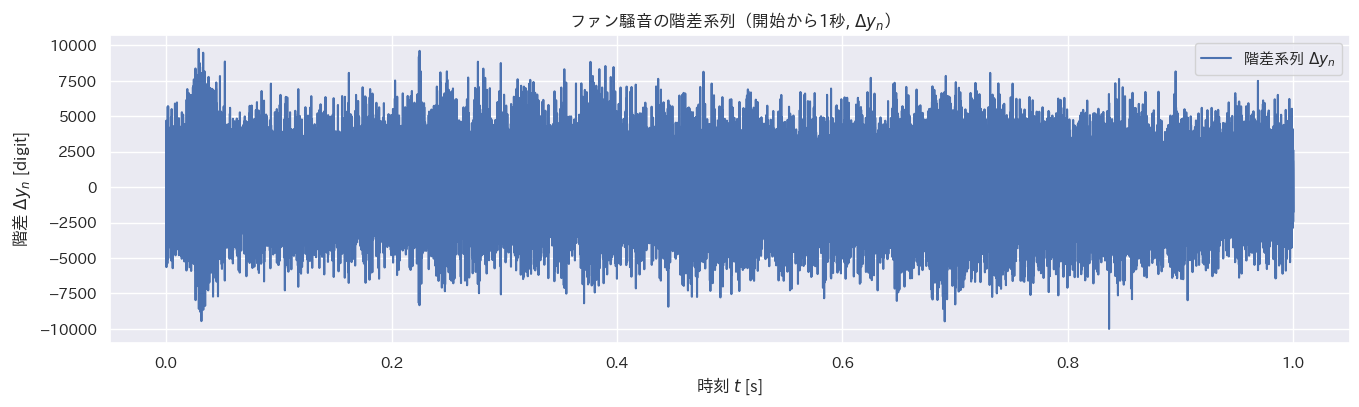

In [15]:
df_timeseries['y_diff'] = df_timeseries['y'].diff()
display(df_timeseries)
ax = df_timeseries.plot(x='t', y='y_diff', figsize=(16,4), label=r'階差系列 $\Delta y_n$')
ax.set_title(r'ファン騒音の階差系列（開始から1秒, $\Delta y_n$）')
ax.set_xlabel('時刻 $t$ [s]')
ax.set_ylabel(r'階差 $\Delta y_n$ [digit]')
ax.legend()
y_diff_series = df_timeseries['y_diff'].dropna()
display(y_diff_series)

ヒストグラムをプロット


Text(0, 0.5, '度数 [count]')

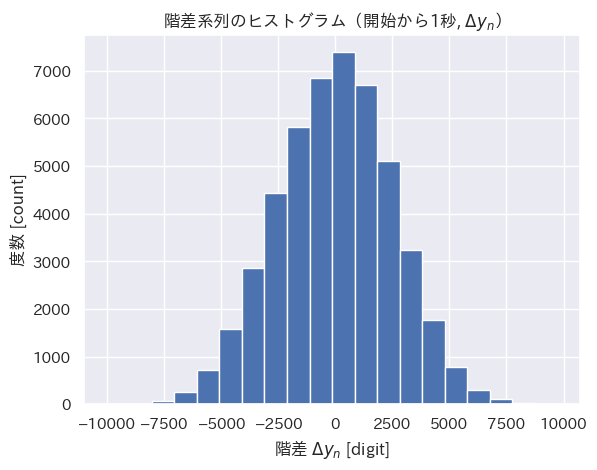

In [16]:
ax = df_timeseries.hist('y_diff', bins=20)
ax0 = ax[0][0]
ax0.set_title(r'階差系列のヒストグラム（開始から1秒, $\Delta y_n$）')
ax0.set_xlabel(r'階差 $\Delta y_n$ [digit]')
ax0.set_ylabel('度数 [count]')

原系列 $y_n$ と階差系列 $\Delta y_n$ のCSVへの出力

In [17]:
#df_timeseries.to_csv('./data/sample02_01.csv',index=False)

## グループワークに利用可能な時系列データの候補

- オープンデータ:
  - 気象庁の気温・降水量・日照時間（時系列が長く、季節性の議論がしやすい）
  - 電力需要実績（時間帯周期・曜日周期を観察しやすい）
  - 交通量データ（通勤時間帯の周期性が明確）
- 既出論文・公開データセット:
  - UCI Machine Learning Repository の時系列データ
  - Kaggle の需要予測・売上予測データセット
  - 論文付録の公開CSV（再現実験向け）
- 研究室・個人の実測データ:
  - 研究室の温湿度センサログ
  - 騒音レベル（dB）や照度の連続観測
  - スマホの加速度・歩数・心拍時系列